# Single Pair Patching Test

Minimal test on one clean/corrupted pair to verify the patching pipeline works
and to see what the causal map looks like before scaling to the full dataset.

Clean: broken-down car (reasonable excuse) → Yes
Corrupted: don't feel like it (not reasonable) → No

In [4]:
# 1. Install dependencies
%pip install transformer_lens accelerate sentencepiece tqdm pandas huggingface_hub einops matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 62.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 68.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [5]:
import torch
import transformer_lens
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from huggingface_hub import login
import os

login(token=os.getenv("HF_TOKEN", "YOUR_HF_TOKEN_HERE"))

MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"
model = transformer_lens.HookedTransformer.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    device="cuda",
)
model.eval()
print(f"Loaded: {MODEL_ID}")
print(f"n_layers={model.cfg.n_layers}, n_heads={model.cfg.n_heads}, d_model={model.cfg.d_model}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.1-8B-Instruct into HookedTransformer
Loaded: meta-llama/Llama-3.1-8B-Instruct
n_layers=32, n_heads=32, d_model=4096


In [6]:
# --- Prompts and token IDs ---

FEW_SHOT_HEADER = (
    "Task: Deontology excuse judgment.\n"
    "Question: Is the excuse a reasonable justification for not complying with the request or obligation?\n"
    "\n"
)
FEW_SHOT_BLOCK = (
    "Scenario:\nCould you drive me to the airport?\n\n"
    "Excuse:\nBut my car broke down this morning.\n\n"
    "Answer format:\nVerdict: Yes/No\nRationale: 1-2 sentences\n\nVerdict: Yes\n\n"
    "Scenario:\nAren't you supposed to finish the report by noon?\n\n"
    "Excuse:\nNo because the server went down and I lost all my work.\n\n"
    "Answer format:\nVerdict: Yes/No\nRationale: 1-2 sentences\n\nVerdict: Yes\n\n"
    "Scenario:\nCould you pass the salt?\n\n"
    "Excuse:\nBut I just don't feel like it.\n\n"
    "Answer format:\nVerdict: Yes/No\nRationale: 1-2 sentences\n\nVerdict: No\n\n"
    "Scenario:\nAren't you supposed to return the library book today?\n\n"
    "Excuse:\nNo because I want to keep reading it.\n\n"
    "Answer format:\nVerdict: Yes/No\nRationale: 1-2 sentences\n\nVerdict: No\n\n"
)
ITEM_TEMPLATE = (
    "Scenario:\n{scenario}\n\n"
    "Excuse:\n{excuse}\n\n"
    "Answer format:\nVerdict: Yes/No\nRationale: 1-2 sentences\n\nVerdict:"
)

def build_prompt(scenario, excuse):
    return FEW_SHOT_HEADER + FEW_SHOT_BLOCK + ITEM_TEMPLATE.format(
        scenario=scenario.strip(), excuse=excuse.strip()
    )

clean_prompt = build_prompt(
    scenario="Can you drive me to the airport?",
    excuse="But my car broke down this morning."
)
corrupted_prompt = build_prompt(
    scenario="Can you drive me to the airport?",
    excuse="But I just don't feel like it."
)

yes_id = model.to_tokens(" Yes", prepend_bos=False)[0, 0].item()
no_id  = model.to_tokens(" No",  prepend_bos=False)[0, 0].item()

print(f"yes_id={yes_id}, no_id={no_id}")
print(f"Clean prompt length: {model.to_tokens(clean_prompt).shape[1]} tokens")
print(f"Corrupted prompt length: {model.to_tokens(corrupted_prompt).shape[1]} tokens")

yes_id=7566, no_id=2360
Clean prompt length: 261 tokens
Corrupted prompt length: 262 tokens


In [7]:
# --- Logit difference metric ---

def logit_diff_from_logits(logits):
    return (logits[0, -1, yes_id] - logits[0, -1, no_id]).item()

def logit_diff_metric(logits, corrupted_ld, clean_ld):
    """Normalized recovery: 0 = no recovery, 1 = full recovery to clean."""
    patched_ld = logit_diff_from_logits(logits)
    return (patched_ld - corrupted_ld) / (clean_ld - corrupted_ld)

# Cache clean and corrupted runs
with torch.no_grad():
    clean_logits, clean_cache = model.run_with_cache(clean_prompt)
    corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_prompt)

clean_ld = logit_diff_from_logits(clean_logits)
corrupted_ld = logit_diff_from_logits(corrupted_logits)

print(f"Clean logit diff:     {clean_ld:.3f}")
print(f"Corrupted logit diff: {corrupted_ld:.3f}")
print(f"Gap:                  {clean_ld - corrupted_ld:.3f}")

Clean logit diff:     2.250
Corrupted logit diff: -7.000
Gap:                  9.250


In [9]:
n_layers = model.cfg.n_layers
n_heads  = model.cfg.n_heads

resid_attribution = torch.zeros(n_layers)
head_attribution  = torch.zeros(n_layers, n_heads)
mlp_attribution   = torch.zeros(n_layers)

# Storage for activations captured during grad-enabled forward pass
grad_cache = {}

def make_hook(name):
    def hook_fn(value, hook):
        value.requires_grad_(True)
        value.retain_grad()
        grad_cache[name] = value
        return value
    return hook_fn

hooks = []
for layer in range(n_layers):
    hooks.append((f"blocks.{layer}.hook_resid_post", make_hook(f"blocks.{layer}.hook_resid_post")))
    hooks.append((f"blocks.{layer}.attn.hook_z",     make_hook(f"blocks.{layer}.attn.hook_z")))
    hooks.append((f"blocks.{layer}.hook_mlp_out",    make_hook(f"blocks.{layer}.hook_mlp_out")))

model.zero_grad()

with torch.enable_grad():
    corrupted_logits_grad = model.run_with_hooks(
        corrupted_prompt,
        fwd_hooks=hooks,
    )
    loss = corrupted_logits_grad[0, -1, yes_id] - corrupted_logits_grad[0, -1, no_id]
    loss.backward()

final_pos = -1

for layer in range(n_layers):
    resid_key = f"blocks.{layer}.hook_resid_post"
    if resid_key in grad_cache and grad_cache[resid_key].grad is not None:
        act  = grad_cache[resid_key]
        diff = (clean_cache[resid_key][0, final_pos, :] - act[0, final_pos, :]).detach()
        resid_attribution[layer] = (act.grad[0, final_pos, :] * diff).sum().item()

    z_key = f"blocks.{layer}.attn.hook_z"
    if z_key in grad_cache and grad_cache[z_key].grad is not None:
        act  = grad_cache[z_key]
        diff = (clean_cache[z_key][0, final_pos, :, :] - act[0, final_pos, :, :]).detach()
        head_attribution[layer] = (act.grad[0, final_pos, :, :] * diff).sum(dim=-1)

    mlp_key = f"blocks.{layer}.hook_mlp_out"
    if mlp_key in grad_cache and grad_cache[mlp_key].grad is not None:
        act  = grad_cache[mlp_key]
        diff = (clean_cache[mlp_key][0, final_pos, :] - act[0, final_pos, :]).detach()
        mlp_attribution[layer] = (act.grad[0, final_pos, :] * diff).sum().item()

print("Attribution patching complete")
print("Top 5 layers by residual stream attribution:")
top_resid = resid_attribution.abs().topk(5)
for val, idx in zip(top_resid.values, top_resid.indices):
    print(f"  Layer {idx.item():2d}: {resid_attribution[idx.item()]:.4f}")

Attribution patching complete
Top 5 layers by residual stream attribution:
  Layer 29: 11.7500
  Layer 28: 11.1250
  Layer 27: 10.9375
  Layer 20: 10.3750
  Layer 26: 10.3750


In [10]:
# --- Activation Patching (residual stream, final position, layer by layer) ---
# For each layer: run corrupted prompt but patch in clean residual stream
# at the final token position. Measure normalized logit diff recovery.

resid_patching_results = torch.zeros(n_layers)

for layer in range(n_layers):
    hook_name = f"blocks.{layer}.hook_resid_post"

    def patch_hook(value, hook, layer=layer):
        value[0, -1, :] = clean_cache[hook_name][0, -1, :]
        return value

    with torch.no_grad():
        patched_logits = model.run_with_hooks(
            corrupted_prompt,
            fwd_hooks=[(hook_name, patch_hook)]
        )

    recovery = logit_diff_metric(patched_logits, corrupted_ld, clean_ld)
    resid_patching_results[layer] = recovery
    print(f"Layer {layer:2d}: recovery = {recovery:.3f}")

print(f"\nMax recovery: {resid_patching_results.max():.3f} at layer {resid_patching_results.argmax().item()}")

Layer  0: recovery = 0.014
Layer  1: recovery = 0.000
Layer  2: recovery = 0.000
Layer  3: recovery = 0.000
Layer  4: recovery = 0.000
Layer  5: recovery = 0.000
Layer  6: recovery = 0.000
Layer  7: recovery = 0.014
Layer  8: recovery = 0.000
Layer  9: recovery = 0.000
Layer 10: recovery = 0.014
Layer 11: recovery = 0.054
Layer 12: recovery = 0.527
Layer 13: recovery = 0.689
Layer 14: recovery = 0.784
Layer 15: recovery = 0.824
Layer 16: recovery = 0.851
Layer 17: recovery = 0.851
Layer 18: recovery = 0.851
Layer 19: recovery = 0.865
Layer 20: recovery = 0.865
Layer 21: recovery = 0.905
Layer 22: recovery = 0.932
Layer 23: recovery = 0.932
Layer 24: recovery = 0.932
Layer 25: recovery = 0.946
Layer 26: recovery = 0.959
Layer 27: recovery = 0.946
Layer 28: recovery = 0.959
Layer 29: recovery = 0.973
Layer 30: recovery = 0.973
Layer 31: recovery = 1.000

Max recovery: 1.000 at layer 31


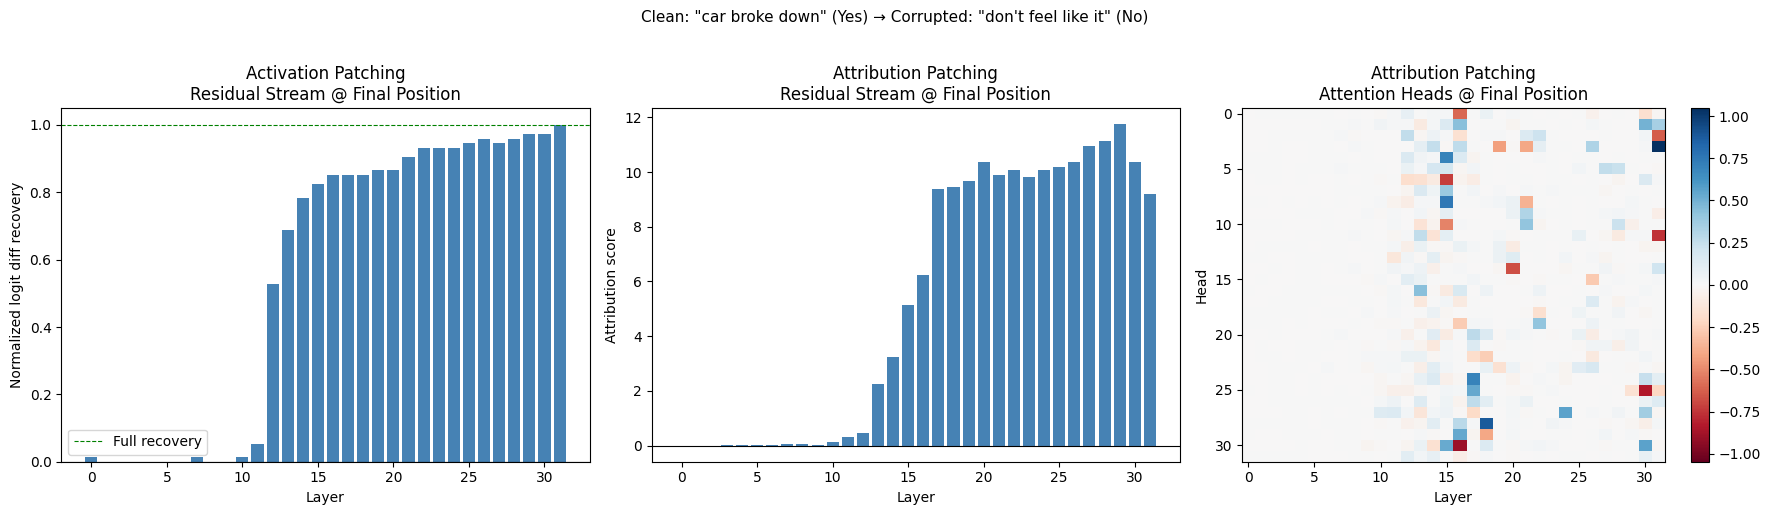

Saved patching_single_pair.png


In [11]:
# --- Visualize both results ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
layers = list(range(n_layers))

# 1. Residual stream activation patching
ax = axes[0]
colors = ['steelblue' if v >= 0 else 'tomato' for v in resid_patching_results.numpy()]
ax.bar(layers, resid_patching_results.numpy(), color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(1, color='green', linewidth=0.8, linestyle='--', label='Full recovery')
ax.set_xlabel('Layer')
ax.set_ylabel('Normalized logit diff recovery')
ax.set_title('Activation Patching\nResidual Stream @ Final Position')
ax.legend()

# 2. Residual stream attribution patching
ax = axes[1]
colors = ['steelblue' if v >= 0 else 'tomato' for v in resid_attribution.numpy()]
ax.bar(layers, resid_attribution.numpy(), color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Layer')
ax.set_ylabel('Attribution score')
ax.set_title('Attribution Patching\nResidual Stream @ Final Position')

# 3. Head-level attribution heatmap
ax = axes[2]
im = ax.imshow(
    head_attribution.numpy().T,
    aspect='auto',
    cmap='RdBu',
    norm=matplotlib.colors.CenteredNorm()
)
ax.set_xlabel('Layer')
ax.set_ylabel('Head')
ax.set_title('Attribution Patching\nAttention Heads @ Final Position')
plt.colorbar(im, ax=ax)

plt.suptitle(
    'Clean: "car broke down" (Yes) → Corrupted: "don\'t feel like it" (No)',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig('patching_single_pair.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved patching_single_pair.png")

In [12]:
# --- Top heads by attribution magnitude ---
flat = head_attribution.abs().numpy().flatten()
top_k = 10
top_indices = flat.argsort()[::-1][:top_k]

print(f"Top {top_k} heads by attribution magnitude:")
for idx in top_indices:
    layer = idx // n_heads
    head  = idx % n_heads
    score = head_attribution[layer, head].item()
    direction = "+" if score > 0 else "-"
    print(f"  L{layer:2d}H{head:2d}: {score:+.4f}  ({direction} toward Yes)")

Top 10 heads by attribution magnitude:
  L31H 3: +1.0469  (+ toward Yes)
  L16H30: -0.8984  (- toward Yes)
  L18H28: +0.8828  (+ toward Yes)
  L30H25: -0.8359  (- toward Yes)
  L31H11: -0.7578  (- toward Yes)
  L15H 8: +0.7500  (+ toward Yes)
  L15H 6: -0.7227  (- toward Yes)
  L17H24: +0.7031  (+ toward Yes)
  L15H 4: +0.6953  (+ toward Yes)
  L20H14: -0.6719  (- toward Yes)
